This notebook shows the analysis of an exemplary image. The image-processing includes the following steps:
- Image pre-processing (rotation, blackening, format change to uint8)
- Segmentation by the trained U-Net
- Image post-processing of the segmented image (morphological operations)
- Contour detection and classification

In [1]:
# import all necessary libraries, classes and functions

import os
import cv2
import sys
import torch
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("development/"))
from unet_architecture import UNet_medium
from unet_training import load_checkpoint, checkpoint_name
from image_enhancer import read_tif, calc_pixel_size
from image_analysis import segment_image, process_bin, fix_contours, classify_contours, contour_cutoff

# choose a device for image segmentation

if torch.cuda.is_available():
    print('GPU is used!')
    DEVICE = 'cuda'
else:
    print('No GPU found, CPU will be used!')
    DEVICE='cpu'

# model properties

MODEL = UNet_medium(1, 1).to(DEVICE)
MODEL_FILE = "model_parameters/" + checkpoint_name
UNET_NAME = checkpoint_name.replace('.pth.tar', '')

# properties of the measurement series

# For the classification of the cavitation regimes into sheet or detached clouds
# it is important to rotate the images to ensure that the flow direction is from
# left to right. Geometrical information about the profile and the angle of attack
# is important for calculating the pixel resolution.

ROTATE180 = True
PROFILE = 'NACA'
ANGLE = 12

profile_dic = {"CLE" : pd.DataFrame({"length in mm" : [40], "depth in mm" : [25]}),
               "NACA" : pd.DataFrame({"length in mm" : [44], "depth in mm" : [25]})}

# image to be analyzed

img_name = 'hssa1002_C001H001S0001000010'

LABEL  = img_name[0:8]
image = f"example_images/{img_name}.tif"

# define colors

tab_orange = (14/255,127/255,255/255)
tab_blue =   (180/255,119/255,31/255)

GPU is used!


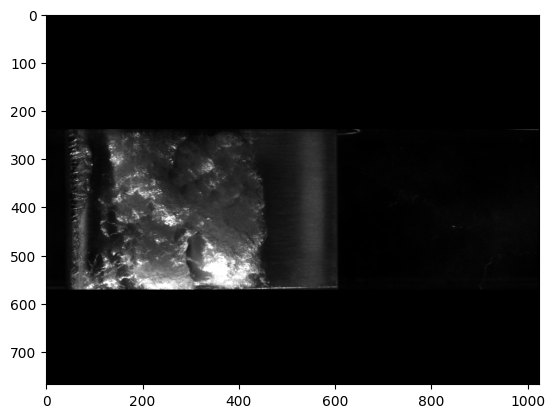

In [2]:
# load meta data
edges = pd.read_csv("example_images/edges.csv")
current_edges = edges.loc[edges['label']==LABEL]
bounds = [current_edges["upper_edge"].values[0], current_edges["lower_edge"].values[0]]
leading_edge = current_edges["leading_edge"].values[0]

pixel_size, pixel_df = calc_pixel_size(current_edges, profile_dic[PROFILE], ANGLE)

# load image
img = read_tif(image, apply_mask=True, rotate180=ROTATE180, bounds=bounds)
axs, fig = plt.subplots(dpi=100)
plt.imshow(img, cmap="gray")

=> Loading U-Net Model
U-Net Model initialised


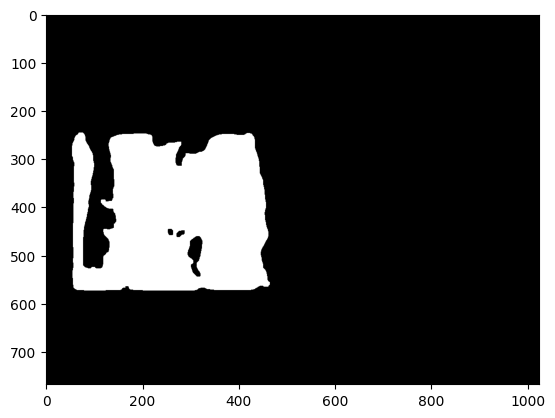

In [3]:
# load model
working_dir = os.getcwd()
os.chdir(working_dir)
load_checkpoint(torch.load(MODEL_FILE, map_location=torch.device('cpu')), MODEL)
MODEL.eval()

# image segmentation + morphological operations
bin_img = segment_image(img, model=MODEL, device=DEVICE)
bin_img_processed = process_bin(bin_img)
axs, fig = plt.subplots(dpi=100)
plt.imshow(bin_img_processed*255, cmap="gray")

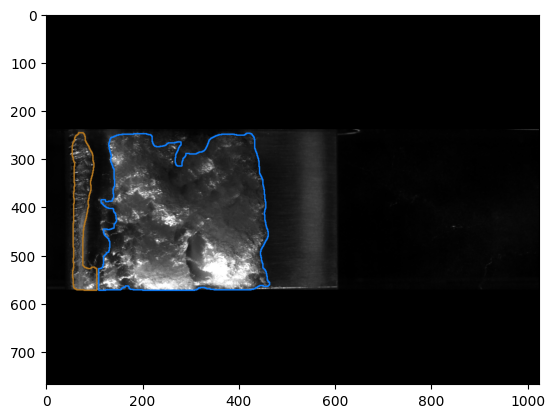

In [4]:
# derive the canny image, find and fix contours
canny_img = cv2.Canny(bin_img_processed,1,2)
contours, _ = cv2.findContours(canny_img,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_NONE)
contour_lst = [obj for obj in contours]
contour_lst = fix_contours(contour_lst)

# classify contours
detachments_nocut, sheet_nocut = classify_contours(contour_lst, vert_thresh=leading_edge)
sheet_cut, detachments_cut, _, _ = contour_cutoff(sheet_nocut, detachments_nocut, bin_img_processed, bounds)

# show image with cavitation outlined
img_col = cv2.cvtColor(img,cv2.COLOR_GRAY2RGB)/255
for cont in sheet_cut:
    cv2.drawContours(img_col,[cont],-1,tab_blue,2)
for cont in detachments_cut:
    cv2.drawContours(img_col,[cont],-1,tab_orange,2)
axs, fig = plt.subplots(dpi=100)
plt.imshow(img_col)